# 01 — Exploratory Data Analysis

Explore the HDB resale dataset: distributions, trends, outliers, and correlations.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../data/hdb_resale_before_2025.csv')
print(df.shape)
df.head()

(196982, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 196982 entries, 0 to 196981
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                196982 non-null  str    
 1   town                 196982 non-null  str    
 2   flat_type            196982 non-null  str    
 3   block                196982 non-null  str    
 4   street_name          196982 non-null  str    
 5   storey_range         196982 non-null  str    
 6   floor_area_sqm       196982 non-null  float64
 7   flat_model           196982 non-null  str    
 8   lease_commence_date  196982 non-null  int64  
 9   remaining_lease      196982 non-null  str    
 10  resale_price         196982 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 16.5 MB


,floor_area_sqm,lease_commence_date,resale_price
count,196982.000000,196982.000000,1.969820e+05
mean,97.008852,1996.191581,5.081563e+05
std,24.029510,14.147343,1.777397e+05
min,31.000000,1966.000000,1.400000e+05
25%,82.000000,1985.000000,3.770000e+05
50%,93.000000,1996.000000,4.780000e+05
75%,112.000000,2011.000000,6.080000e+05
max,366.700000,2021.000000,1.588000e+06


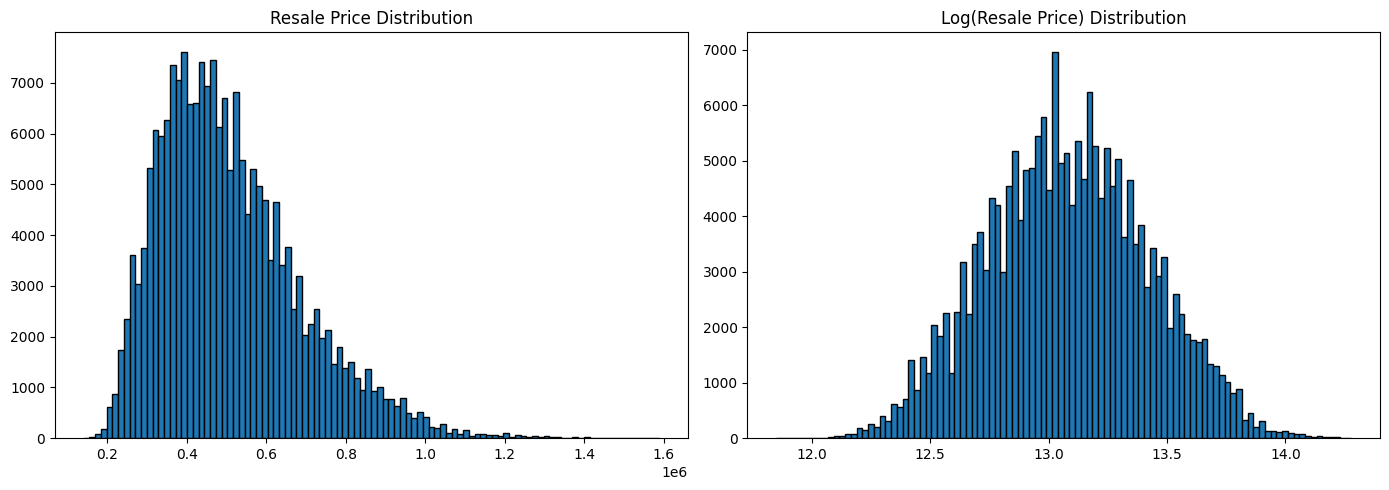

In [5]:
# Resale price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['resale_price'], bins=100, edgecolor='black')
axes[0].set_title('Resale Price Distribution')
axes[1].hist(np.log1p(df['resale_price']), bins=100, edgecolor='black')
axes[1].set_title('Log(Resale Price) Distribution')
plt.tight_layout()
plt.show()

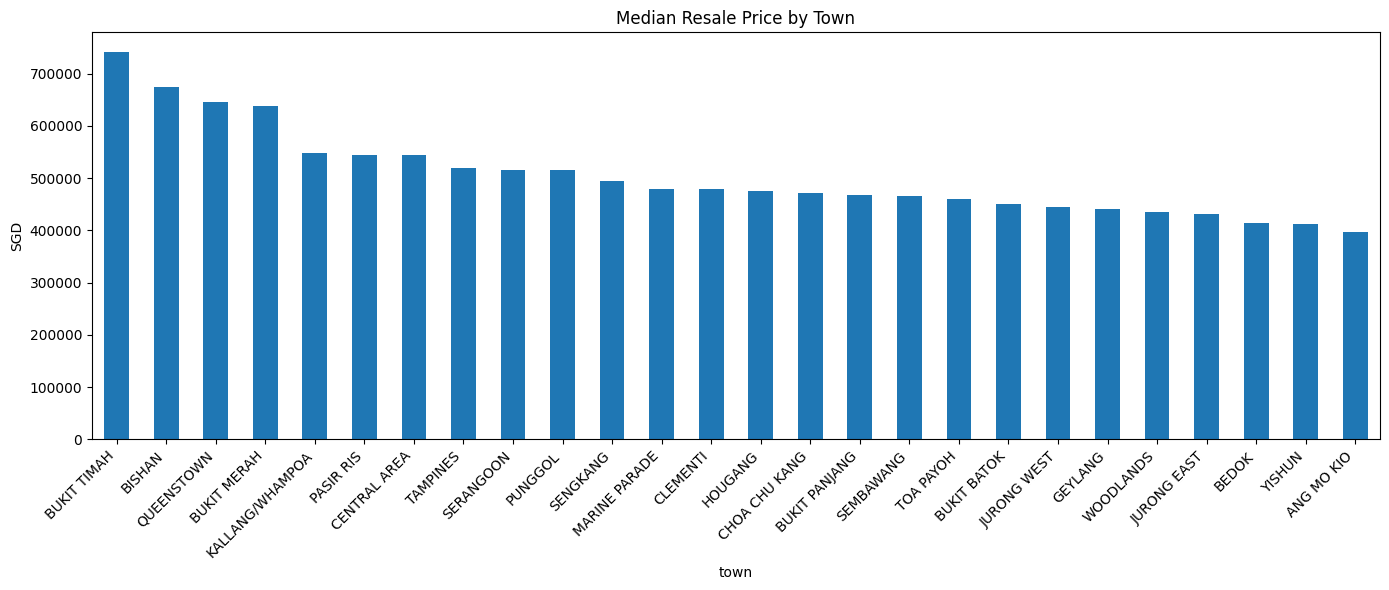

In [6]:
# Price by town
town_median = df.groupby('town')['resale_price'].median().sort_values(ascending=False)
plt.figure(figsize=(14, 6))
town_median.plot(kind='bar')
plt.title('Median Resale Price by Town')
plt.ylabel('SGD')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

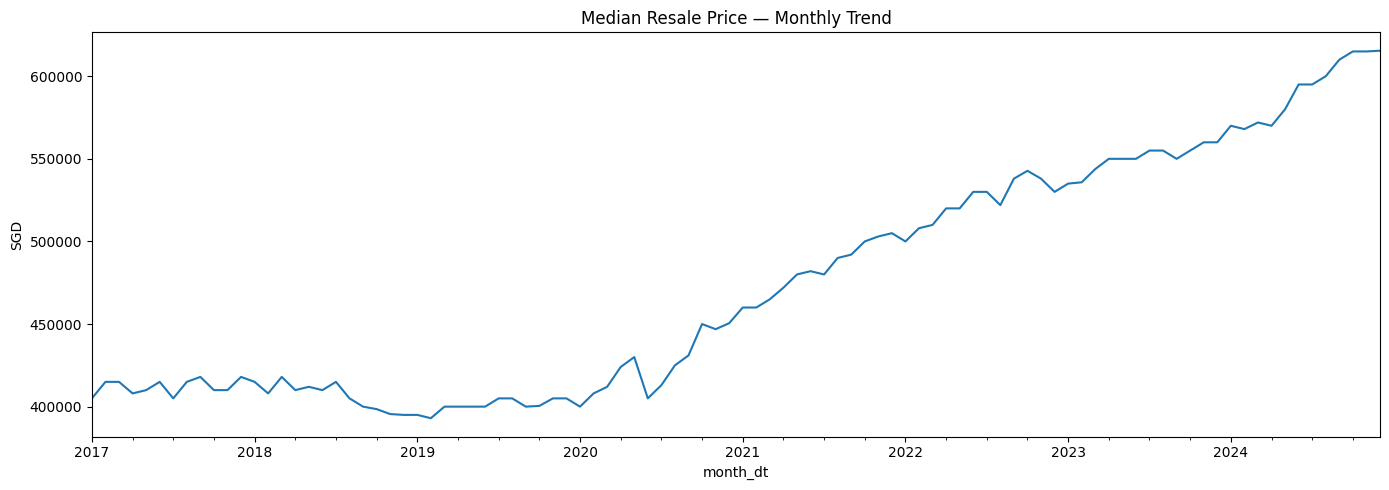

In [7]:
# Price trend over time
df['month_dt'] = pd.to_datetime(df['month'])
monthly = df.groupby('month_dt')['resale_price'].median()
plt.figure(figsize=(14, 5))
monthly.plot()
plt.title('Median Resale Price — Monthly Trend')
plt.ylabel('SGD')
plt.tight_layout()
plt.show()